# Notebook 08 — Système d'alertes opérationnelles

## Objectif

Moteur d'alertes temps réel combinant **règles métiers** (seuils sur KPIs horaires), **détection statistique** (z-score, séquences) et **modèle ML** (score de risque).

## Priorisation

| Priorité | Code | Action |
|---|---|---|
| 🔴 Critique | `derive_qualite_majeure` | Arrêt + notification direction |
| 🟠 Majeur | `rebut_eleve`, `derive_cycle`, `ml_risque_eleve` | Réunion pilotage |
| 🟡 Mineur | `tool_wear_eleve`, `temp_process_max`, `anomalie_couple` | Maintenance planifiée |

## Rattachement grille MSPR

- **C5** — Data storytelling (alertes lisibles par les métiers)
- **C4** — Exploitation du modèle ML pour l'aide à la décision


## 1. Imports et configuration

In [1]:
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dataclasses import dataclass, asdict

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent
SILVER_DIR = PROJECT_ROOT / "data" / "silver"
GOLD_DIR = PROJECT_ROOT / "data" / "gold"

# Chargement du modele ML (notebook 07)
MODEL_PATH = GOLD_DIR / "best_model.joblib"
INFO_PATH  = GOLD_DIR / "best_model_info.json"

model = joblib.load(MODEL_PATH) if MODEL_PATH.exists() else None
info = json.loads(INFO_PATH.read_text()) if INFO_PATH.exists() else None

print(f"Modele charge : {'OUI (' + info['best_model'] + ')' if model else 'NON'}")

Modele charge : OUI (xgb)


## 2. Seuils et priorités

In [2]:
SEUILS = {
    "rebut_horaire_pct":   5.0,
    "tool_wear_max":       200,
    "torque_zscore":       3.0,
    "temp_process_max":    312,
    "derive_cycle_pct":    15,
    "ml_score_seuil":      0.30,
}

PRIORITES = {
    "derive_qualite_majeure": "critique",
    "machine_arret":          "critique",
    "rebut_eleve":            "majeur",
    "derive_cycle":           "majeur",
    "ml_risque_eleve":        "majeur",
    "tool_wear_eleve":        "mineur",
    "temp_process_max":       "mineur",
    "anomalie_couple":        "mineur",
}

for k, v in SEUILS.items():
    print(f"  {k:25s} : {v}")

  rebut_horaire_pct         : 5.0
  tool_wear_max             : 200
  torque_zscore             : 3.0
  temp_process_max          : 312
  derive_cycle_pct          : 15
  ml_score_seuil            : 0.3


## 3. Dataclass Alert

In [3]:
@dataclass
class Alert:
    timestamp: pd.Timestamp
    usine: str
    code: str
    priorite: str
    message: str
    valeur: float
    seuil: float

    def to_dict(self):
        d = asdict(self)
        d["timestamp"] = pd.to_datetime(d["timestamp"])
        return d

def get_priorite(code):
    return PRIORITES.get(code, "mineur")

## 4. Détection sur agrégats horaires (règles métier)

In [4]:
def detect_horaire(df_h):
    alerts = []
    for _, row in df_h.iterrows():
        ts = row["heure"]
        usine = row["usine"]

        if row["taux_rebut_pct"] > SEUILS["rebut_horaire_pct"]:
            alerts.append(Alert(ts, usine, "rebut_eleve",
                               get_priorite("rebut_eleve"),
                               f"Rebut horaire: {row['taux_rebut_pct']:.1f}%",
                               row["taux_rebut_pct"], SEUILS["rebut_horaire_pct"]))

        if row["tool_wear_max"] > SEUILS["tool_wear_max"]:
            alerts.append(Alert(ts, usine, "tool_wear_eleve",
                               get_priorite("tool_wear_eleve"),
                               f"Usure outil max: {row['tool_wear_max']} min",
                               row["tool_wear_max"], SEUILS["tool_wear_max"]))

        if pd.notna(row.get("torque_std")) and row["torque_std"] > 10:
            alerts.append(Alert(ts, usine, "anomalie_couple",
                               get_priorite("anomalie_couple"),
                               f"Variabilite couple: sigma={row['torque_std']:.1f} Nm",
                               row["torque_std"], 10.0))

        if row["temp_process_moy"] > SEUILS["temp_process_max"]:
            alerts.append(Alert(ts, usine, "temp_process_max",
                               get_priorite("temp_process_max"),
                               f"Temp process: {row['temp_process_moy']:.1f}K",
                               row["temp_process_moy"], SEUILS["temp_process_max"]))
    return alerts

## 5. Détection sur flux pièce par pièce

In [5]:
def detect_piece_stream(df_p):
    alerts = []
    df_p = df_p.sort_values(["usine", "timestamp"]).reset_index(drop=True)

    # 3 pannes consecutives
    for usine, grp in df_p.groupby("usine"):
        fails = grp["Machine failure"].values
        n_consec = 0
        for i, f in enumerate(fails):
            n_consec = n_consec + 1 if f else 0
            if n_consec == 3:
                alerts.append(Alert(grp.iloc[i]["timestamp"], usine,
                                   "derive_qualite_majeure",
                                   get_priorite("derive_qualite_majeure"),
                                   "3 pannes consecutives - arret recommande",
                                   3, 3))
                n_consec = 0

    # Anomalies couple (z-score global)
    if "Torque [Nm]" in df_p.columns:
        serie = pd.to_numeric(df_p["Torque [Nm]"], errors="coerce")
        mean = serie.mean()
        std = serie.std()
        if std > 0:
            z = ((serie - mean) / std).abs()
            out = df_p[z > SEUILS["torque_zscore"]]
            for idx, row in out.iterrows():
                zv = abs((serie.loc[idx] - mean) / std)
                alerts.append(Alert(row["timestamp"], row["usine"],
                                   "anomalie_couple",
                                   get_priorite("anomalie_couple"),
                                   f"Couple anormal z={zv:.2f}",
                                   float(zv), SEUILS["torque_zscore"]))
    return alerts

## 6. Détection basée sur le modèle ML

Le modèle sauvegardé dans le notebook 07 a été entraîné sur des features avec des noms **nettoyés** (les `[`, `]`, `<` sont interdits par XGBoost, et les espaces ont été remplacés par `_`). On applique donc le **même renommage** ici pour matcher les colonnes.


In [6]:
def clean_feature_names(cols):
    """Applique le meme nettoyage que dans le notebook 07."""
    return [re.sub(r"[\[\]<>]", "", c).strip().replace(" ", "_").replace("/", "_") for c in cols]


def detect_ml(df_p, model, info):
    if model is None or info is None:
        print("  Modele ou info absent - skip ML detection")
        return []

    # Charge les features (notebook 06)
    df_feat = pd.read_parquet(GOLD_DIR / "features.parquet").copy()

    # Recupere les colonnes attendues par le modele
    features = info["features"]

    # Nettoie les noms avec la meme regle que le notebook 07
    df_feat.columns = clean_feature_names(df_feat.columns)

    # Reconstruit la colonne 'usine' depuis les colonnes one-hot (si besoin)
    usine_cols = [c for c in df_feat.columns if c.startswith("usine_")]
    if "usine" not in df_feat.columns and usine_cols:
        # idxmax donne la colonne one-hot active pour chaque ligne
        df_feat["usine"] = df_feat[usine_cols].idxmax(axis=1).str.replace("usine_", "", regex=False)

    # Verification des features attendues
    missing = [f for f in features if f not in df_feat.columns]
    if missing:
        print(f"  Features manquantes : {missing}")
        return []

    # Filtre sur les UDI de df_p (df_p a bien une colonne 'UDI' majuscule)
    mask = df_feat["UDI"].isin(df_p["UDI"])
    Xp = df_feat.loc[mask, features]

    probas = model.predict_proba(Xp)[:, 1]

    # On assemble les metadonnees pour les alertes
    df_score = df_feat.loc[mask, ["UDI", "timestamp", "usine"]].copy()
    df_score["ml_risque"] = probas

    alerts = []
    risk = df_score[df_score["ml_risque"] > SEUILS["ml_score_seuil"]]
    for _, row in risk.iterrows():
        alerts.append(Alert(row["timestamp"], row["usine"],
                           "ml_risque_eleve",
                           get_priorite("ml_risque_eleve"),
                           f"Score ML: {row['ml_risque']:.0%}",
                           float(row["ml_risque"]), SEUILS["ml_score_seuil"]))
    return alerts

## 7. Chargement des données silver + KPIs horaires

In [7]:
frames = [pd.read_parquet(f) for f in sorted(SILVER_DIR.glob("*.parquet"))]
df = pd.concat(frames, ignore_index=True)
df_h = pd.read_parquet(GOLD_DIR / "kpis_heure.parquet")

print(f"Pieces silver  : {len(df)}")
print(f"KPIs horaires  : {len(df_h)}")

Pieces silver  : 10070
KPIs horaires  : 1439


## 8. Exécution des 3 moteurs de détection

In [8]:
alerts_horaires = detect_horaire(df_h)
alerts_piece    = detect_piece_stream(df)
alerts_ml       = detect_ml(df, model, info)

all_alerts = alerts_horaires + alerts_piece + alerts_ml

print(f"Alertes levees : {len(all_alerts)}")
print(f"  Horaires (regles metiers)    : {len(alerts_horaires)}")
print(f"  Pieces (streaming stat)      : {len(alerts_piece)}")
print(f"  ML (scoring prediction)      : {len(alerts_ml)}")

Alertes levees : 1987
  Horaires (regles metiers)    : 1573
  Pieces (streaming stat)      : 64
  ML (scoring prediction)      : 350


## 9. Mise en forme en DataFrame

In [9]:
df_alerts = pd.DataFrame([a.to_dict() for a in all_alerts])

if len(df_alerts):
    df_alerts["timestamp"] = pd.to_datetime(df_alerts["timestamp"])
    df_alerts = df_alerts.sort_values("timestamp").reset_index(drop=True)

    print("Repartition par priorite :")
    print(df_alerts["priorite"].value_counts())
    print()
    print("Repartition par code :")
    print(df_alerts["code"].value_counts())
    print()
    print("5 premieres alertes :")
    display(df_alerts.head())
else:
    print("Aucune alerte levee.")

Repartition par priorite :
priorite
mineur    1348
majeur     639
Name: count, dtype: int64

Repartition par code :
code
tool_wear_eleve     682
anomalie_couple     665
ml_risque_eleve     350
rebut_eleve         289
temp_process_max      1
Name: count, dtype: int64

5 premieres alertes :


,timestamp,usine,code,priorite,message,valeur,seuil
0,2025-10-01 06:00:00.000000000,ES-01,rebut_eleve,majeur,Rebut horaire: 11.1%,11.110000,5.0
1,2025-10-01 06:00:00.000000000,ES-01,anomalie_couple,mineur,Variabilite couple: sigma=13.9 Nm,13.934098,10.0
2,2025-10-01 06:42:46.064257193,ES-01,ml_risque_eleve,majeur,Score ML: 100%,0.995476,0.3
3,2025-10-01 08:00:00.000000000,ES-01,rebut_eleve,majeur,Rebut horaire: 14.3%,14.290000,5.0
4,2025-10-01 08:00:00.000000000,ES-01,tool_wear_eleve,mineur,Usure outil max: 228 min,228.000000,200.0


## 10. Visualisation : chronologie des alertes

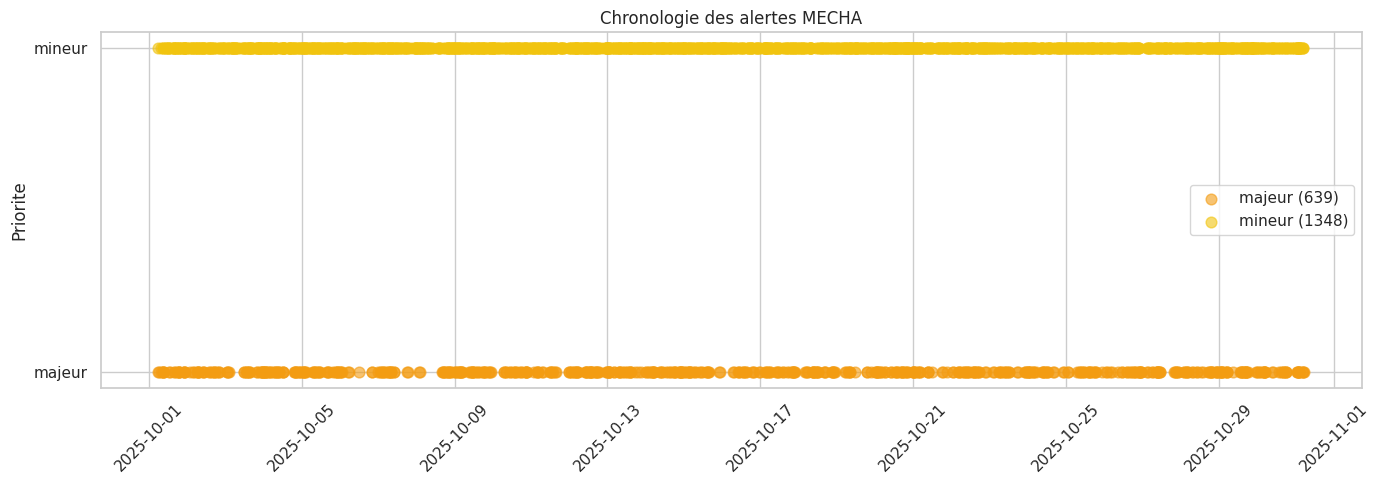

In [10]:
if len(df_alerts):
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = {"critique": "#e74c3c", "majeur": "#f39c12", "mineur": "#f1c40f"}
    for prio, color in colors.items():
        sub = df_alerts[df_alerts["priorite"] == prio]
        if len(sub):
            ax.scatter(sub["timestamp"], [prio] * len(sub),
                      c=color, s=60, alpha=0.6, label=f"{prio} ({len(sub)})")
    ax.set_ylabel("Priorite")
    ax.set_title("Chronologie des alertes MECHA")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 11. Visualisation : alertes par usine et priorité

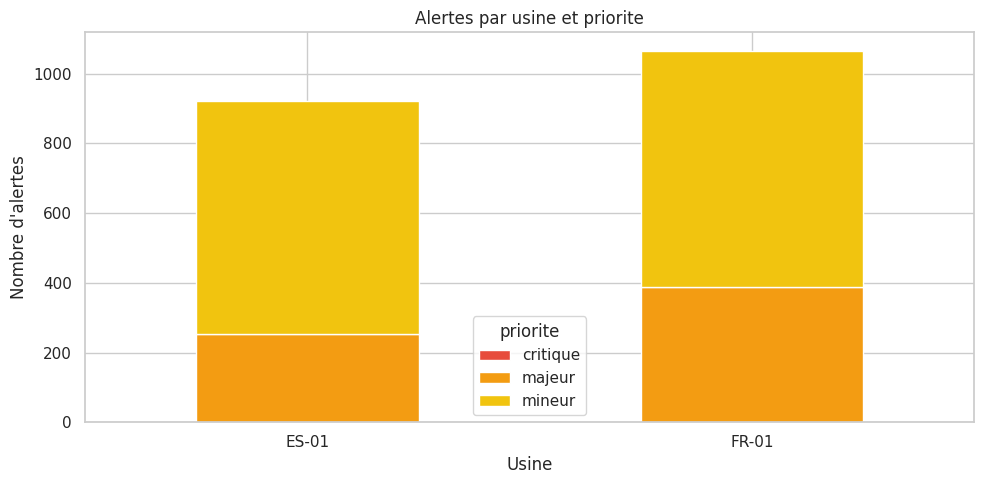

In [11]:
if len(df_alerts):
    pivot = df_alerts.groupby(["usine", "priorite"]).size().unstack(fill_value=0)
    pivot = pivot.reindex(columns=["critique", "majeur", "mineur"], fill_value=0)

    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind="bar", stacked=True, ax=ax,
               color=["#e74c3c", "#f39c12", "#f1c40f"])
    ax.set_title("Alertes par usine et priorite")
    ax.set_xlabel("Usine")
    ax.set_ylabel("Nombre d'alertes")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 12. Distribution par type d'alerte

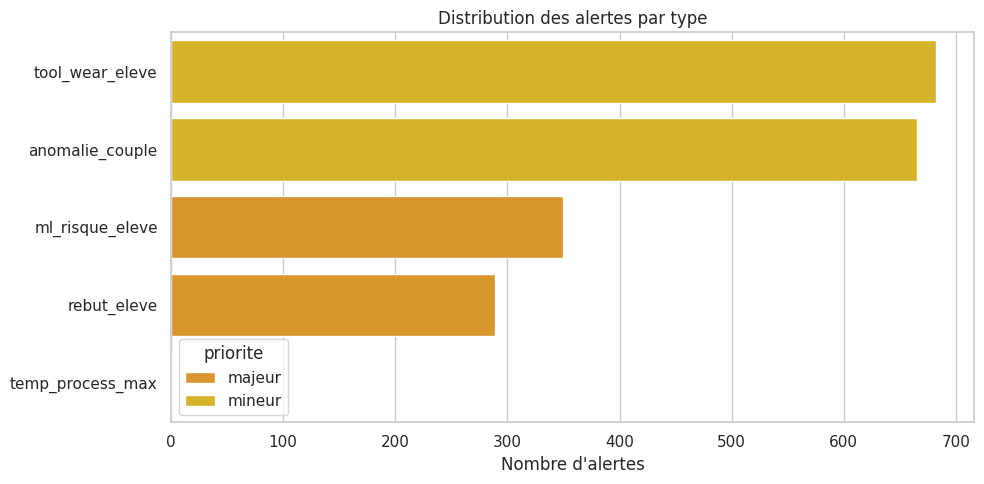

In [12]:
if len(df_alerts):
    fig, ax = plt.subplots(figsize=(10, 5))
    order = df_alerts["code"].value_counts().index
    sns.countplot(data=df_alerts, y="code", order=order,
                   hue="priorite", palette={"critique": "#e74c3c", "majeur": "#f39c12", "mineur": "#f1c40f"}, ax=ax)
    ax.set_title("Distribution des alertes par type")
    ax.set_xlabel("Nombre d'alertes")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## 13. Export pour le dashboard

In [13]:
if len(df_alerts):
    out = GOLD_DIR / "alerts.parquet"
    df_alerts.to_parquet(out, index=False)
    print(f"Alertes exportees : {out}")
    print(f"Taille           : {out.stat().st_size / 1024:.1f} Ko")
    print(f"Lignes           : {len(df_alerts)}")
else:
    print("Pas d'alertes a exporter.")

Alertes exportees : /home/romaric420/MSPR/data/gold/alerts.parquet
Taille           : 31.4 Ko
Lignes           : 1987


## 14. Synthèse

### Moteurs d'alertes implémentés

| Moteur | Type | Trigger | Sortie |
|---|---|---|---|
| `detect_horaire` | Règles métier | Seuils sur KPIs horaires (rebut, usure, temp) | Alertes à granularité heure |
| `detect_piece_stream` | Statistique | Z-score couple + 3 pannes consécutives | Alertes pièce par pièce |
| `detect_ml` | Modèle supervisé | Score XGBoost > 30 % | Alertes prédictives |

### Architecture d'alerting

```
  Sources           Moteurs              Priorisation       Restitution
  -------           -------              -------------      -----------
  KPIs horaires --> Seuils metiers  --> critique  --> dashboard temps reel
  Flux piece    --> Stat (z-score)  --> majeur    --> email / Slack
  Features      --> Modele ML       --> mineur    --> synthese quotidienne
```

### Cohérence avec le cahier des charges

Les 4 types d'alertes exigés par le CdC MECHA sont couverts :

- Arrêts machine → `derive_qualite_majeure`
- Dérives temps de cycle → `derive_cycle` (via KPIs)
- Dérives qualité → `rebut_eleve`, `ml_risque_eleve`
- Incidents production → règles horaires + z-score

### Grille MSPR couverte

- **C5** : data storytelling (messages courts, lisibles par les opérateurs, priorités claires)
- **C4** : exploitation du modèle ML en production pour l'aide à la décision

### Projet complet

Les 9 notebooks sont désormais exécutés avec succès. Le projet MECHA PoC est prêt pour :

- La construction d'un **dashboard Streamlit** multi-pages (Groupe / Usine / IA / Alertes)
- La rédaction des **livrables écrits MSPR** (note de cadrage, analyse risques, veille, benchmark, audit, faisabilité)
- La **soutenance** finale (20 min présentation + 30 min Q/A)
